### TODOS
- Do analysis short vs. long sequences
- Length comparison how well does whisper legnth correlate with real length
- Are short sequences more often wrong than long sequences?
- F1 at predicting short sequences vs long sequences
- LLM with context
- fix space and casing issue


### TODOs (Suryansh)
2. Stop word analysis for GT and generated

In [1]:
import pandas as pd
import os
from tqdm.auto import tqdm
from llm_asr_clarification.constants import SAMPLE_MEETINGS
import json
import torch
import torch.nn.functional as F
from rouge_score import rouge_scorer
from transformers import AutoTokenizer
from jiwer import wer
import jiwer

# Define a robust transformation pipeline
# This applies data cleaning steps in order, from top to bottom
JIWER_TRANSFORM = jiwer.Compose([
    jiwer.ToLowerCase(),                # Convert all text to lowercase
    jiwer.RemovePunctuation(),          # Strip characters like commas, periods, question marks
    jiwer.RemoveMultipleSpaces(),       # Turn multi-spaces into a single space
    jiwer.Strip(),                      # Clean up leading/trailing whitespaces
    jiwer.ReduceToListOfListOfWords()   # Format text tokens perfectly for jiwer's internal engine
])


pd.set_option('display.max_colwidth', None)

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"   # or another causal LM
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
scorer = rouge_scorer.RougeScorer(
    ["rougeL"],
    # use_stemmer=True,
    use_stemmer=False
)

def rouge_l(pred, ref):
    return scorer.score(
        ref,   # reference first
        pred   # prediction second
    )["rougeL"]

def load_df_from_path(AMI_PATH):
    meeting_paths = [entry.path for entry in os.scandir(AMI_PATH)]
        
    data = []
    for meeting_path in tqdm(meeting_paths):
        beam_results = os.path.join(meeting_path, "artifacts", "beam_results.json")
        try:
            with open(beam_results, "r", encoding="utf-8") as f:
                lines = f.read()
            lines = json.loads(lines)
        except Exception as err:
            print(f"couldnt open file {beam_results}")
            continue
    
        # Process lines
        for line in lines:
            for i in range(1,6):
                beam_no = f'beam_{i}'
                beam = line.pop(beam_no)
    
                line[f"{beam_no}_text"] = beam["text"]
                line[f"{beam_no}_asrlogprob"] = beam["asr_avg_log_prob"]
                line[f"{beam_no}_llmlogprob"] = beam["llm_avg_log_prob"]
            line["meeting_name"] = meeting_path.split("/")[-1]

            data.append(line)
            
    # df = pd.DataFrame(lines)
    df = pd.DataFrame(data)
    return df
    
AMI_TRAIN_PATH = '/group/jrwhitehill/amicorpus/train'
AMI_VAL_PATH = '/group/jrwhitehill/amicorpus/validation'

df = load_df_from_path(AMI_TRAIN_PATH)
df_val = load_df_from_path(AMI_VAL_PATH)

/home/pkongsomjit/miniconda3/envs/llm_clarification/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 18/18 [00:00<00:00, 159.63it/s]


In [2]:
print(df.shape)
print(df_val.shape)

(88717, 17)
(10590, 17)


In [3]:
df.head(3)

,gt,beam_1_text,beam_1_asrlogprob,beam_1_llmlogprob,beam_2_text,beam_2_asrlogprob,beam_2_llmlogprob,beam_3_text,beam_3_asrlogprob,beam_3_llmlogprob,beam_4_text,beam_4_asrlogprob,beam_4_llmlogprob,beam_5_text,beam_5_asrlogprob,beam_5_llmlogprob,meeting_name
0,Okay.,Okay.,-0.165992,-10.1875,Okay.,-0.165992,-10.18750,Okay.,-0.165992,-10.1875,OK.,-0.808041,-11.0000,Okay.,-0.165992,-10.1875,ES2005d
1,"Okay, almost there.",Okay.,-0.202354,-10.1875,Okay. I want to say.,-0.761428,-5.21875,Okay.,-0.202354,-10.1875,Okay.,-0.202354,-10.1875,Okay. I was there.,-0.371616,-5.5000,ES2005d
2,Okay.,Okay,-0.634828,-17.0000,Ok,-2.403044,-19.62500,Okay.,-0.134573,-10.1875,OK.,-0.716196,-11.0000,Okay.,-0.134573,-10.1875,ES2005d


In [4]:
import re
import string

def normalize_text(text: str) -> str:
    """Mirrors the jiwer text normalization pipeline, except for last stage"""
    if not text:
        return ""
    
    # 1. jiwer.ToLowerCase()
    text = text.lower()
    
    # 2. jiwer.RemovePunctuation()
    # Removes standard punctuation: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 3. jiwer.RemoveMultipleSpaces()
    text = re.sub(r'\s+', ' ', text)
    
    # 4. jiwer.Strip()
    text = text.strip()
    
    return text

In [5]:
def process_columns(df):
    llm_logprob_columns = [f'beam_{i}_llmlogprob' for i in range(1,6)]
    asr_logprob_columns = [f'beam_{i}_asrlogprob' for i in range(1,6)]
    
    llm_logprobs = torch.tensor(df[llm_logprob_columns].values)
    asr_logprobs = torch.tensor(df[asr_logprob_columns].values)
    
    # # ALL BEAMS
    # scores = F.softmax(ALPHA*llm_logprobs + 0.0asr_logprobs, dim=1)
    # highest_score_idxs = torch.argmax(scores, dim=1, keepdim=True)
    # highest_scores = torch.gather(scores, dim=1, index=highest_score_idxs)

    # JUST BEAM 1
    scores = llm_logprobs
    highest_scores = scores[torch.arange(scores.size(0)), torch.zeros(scores.size(0), dtype=torch.long)]


    # AGGREGATED STATS
    df['max_llmlogprobs'] = torch.max(llm_logprobs, dim=1).values.numpy()
    df['min_llmlogprobs'] = torch.min(llm_logprobs, dim=1).values.numpy()
    df['spread_llmlogprobs'] = df['max_llmlogprobs'] - df['min_llmlogprobs']

    df['max_asrlogprobs'] = torch.max(asr_logprobs, dim=1).values.numpy()
    df['min_asrlogprobs'] = torch.min(asr_logprobs, dim=1).values.numpy()
    df['spread_asrlogprobs'] = df['max_asrlogprobs'] - df['min_asrlogprobs']

    df['highest_score'] = highest_scores.numpy()
    
    df['text'] = df['beam_1_text']
    df['num_tokens_text'] = df['beam_1_text'].apply(
        lambda x: len(tokenizer.encode(x))
    )
    df['num_tokens_gt'] = df['gt'].apply(
        lambda x: len(tokenizer.encode(x))
    )
    
    
    df["rougeL"] = [
        rouge_l(normalize_text(pred), normalize_text(ref)).fmeasure
        for pred, ref in zip(df["text"], df["gt"])
    ]
    df["wer"] = [
        min(1.0, wer(reference = ref, hypothesis = pred, reference_transform = JIWER_TRANSFORM, hypothesis_transform = JIWER_TRANSFORM))
        for pred, ref in zip(df["text"], df["gt"])
    ]

process_columns(df)
process_columns(df_val)

In [6]:
df.head(5)

,gt,beam_1_text,beam_1_asrlogprob,beam_1_llmlogprob,beam_2_text,beam_2_asrlogprob,beam_2_llmlogprob,beam_3_text,beam_3_asrlogprob,beam_3_llmlogprob,...,spread_llmlogprobs,max_asrlogprobs,min_asrlogprobs,spread_asrlogprobs,highest_score,text,num_tokens_text,num_tokens_gt,rougeL,wer
0,Okay.,Okay.,-0.165992,-10.18750,Okay.,-0.165992,-10.18750,Okay.,-0.165992,-10.18750,...,0.81250,-0.165992,-0.808041,0.642049,-10.18750,Okay.,3,3,1.000000,0.000000
1,"Okay, almost there.",Okay.,-0.202354,-10.18750,Okay. I want to say.,-0.761428,-5.21875,Okay.,-0.202354,-10.18750,...,4.96875,-0.202354,-0.761428,0.559074,-10.18750,Okay.,3,6,0.500000,0.666667
2,Okay.,Okay,-0.634828,-17.00000,Ok,-2.403044,-19.62500,Okay.,-0.134573,-10.18750,...,9.43750,-0.134573,-2.403044,2.268470,-17.00000,Okay,2,3,1.000000,0.000000
3,"We'll sta I'll use the PowerPoint, I guess.","Oh well, I'll use the PowerPoint, I guess.",-0.256419,-4.90625,"well, I'll use the powerpoint I guess.",-0.460730,-6.03125,"Well, I'll use the PowerPoint, I guess.",-0.103038,-5.28125,...,2.43750,-0.103038,-0.460730,0.357692,-4.90625,"Oh well, I'll use the PowerPoint, I guess.",13,13,0.875000,0.250000
4,"How was that, was that fun?","How was that, was that?",-0.126335,-6.53125,"I was that, was that.",-0.454225,-8.18750,I was that was enough.,-0.371302,-9.18750,...,2.65625,-0.126335,-0.454225,0.327890,-6.53125,"How was that, was that?",8,9,0.909091,0.166667


# whisper text len vs. ground truth text len

In [7]:
import matplotlib.pyplot as plt

def corr_analysis(df, x='highest_score', y='rougeL'):
    df.plot.scatter(x=x, y=y)
    
    # Display the plot
    plt.show()
    
    from scipy.stats import pearsonr
    
    result = pearsonr(df[x], df[y])
    
    print(f"Pearson r: {result.statistic:.4f}")
    print(f"P-value: {result.pvalue:.4f}")

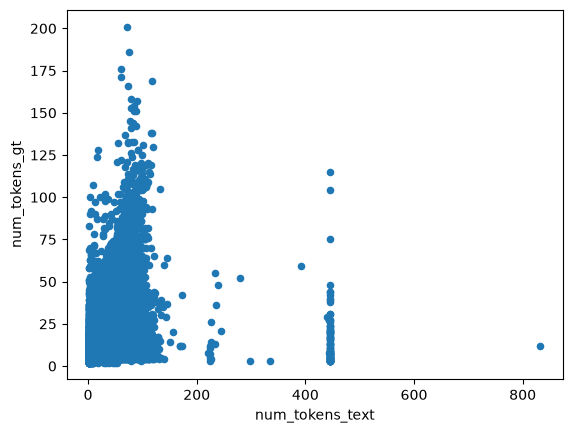

Pearson r: 0.5448
P-value: 0.0000


In [8]:
corr_analysis(df,'num_tokens_text','num_tokens_gt')

In [9]:
# Filter out seqs with tokens greater than or equal to 400 in the generated text
df = df[df['num_tokens_text'] < 400]
df_val = df_val[df_val['num_tokens_text'] < 400]

short_idx = df['num_tokens_text'] <= 5

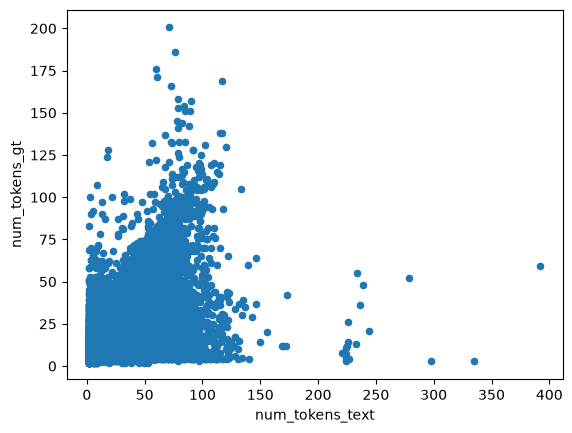

Pearson r: 0.7294
P-value: 0.0000


In [10]:
corr_analysis(df,'num_tokens_text','num_tokens_gt')

<Axes: >

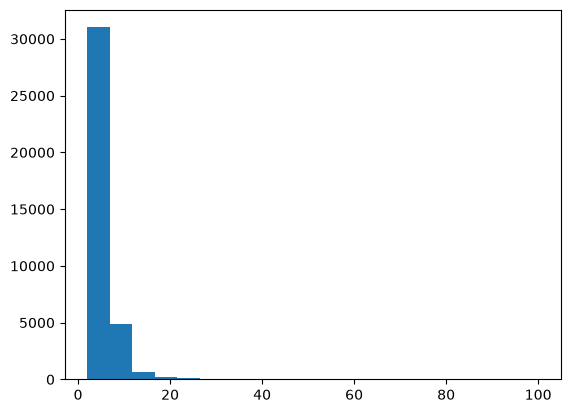

In [11]:
df[short_idx]['num_tokens_gt'].hist(bins=20, grid=False)

In [12]:
# Number of short sequences
sum(short_idx)

37016

In [13]:
# Get the number of times GT sequences were longer than generated
sum((df['num_tokens_gt'] > df['num_tokens_text']))

54926

In [14]:
# Num of times GT sequences are longer than generated short seqs
sum((df['num_tokens_gt'] > df['num_tokens_text']) & (short_idx))

28401

In [15]:
# % of GT seqs longer than generated short seqs 
len(df[((df['num_tokens_gt'] > df['num_tokens_text']) & (short_idx))])/len(df[short_idx])

0.7672628052733953

In [16]:
# % of when long seqs had short transcriptions (mostly mistranscriptions)
len(df[((df['num_tokens_gt'] > 5) & (short_idx))])/len(df[short_idx])

0.2917387075859088

In [17]:
# Sample 10 generated short seqs and their equivalent GT
df[short_idx][['text','gt']].sample(10)

,text,gt
65433,Right,"Right, right."
79661,the,"Let's see one, two God damn it."
44838,You,Uh-huh.
77288,you,No.
65692,you,Okay.
8826,the Crownlands.,"Oh, okay."
61664,you,Okay.
29147,like a new,Like a phone.
20538,Yeah,"And the video also, or not uh?"
47834,Thank you.,Do you know the phone?


# errors analysis

In [18]:
df['wer'].describe()

count    88630.000000
mean         0.715794
std          0.342662
min          0.000000
25%          0.408163
50%          1.000000
75%          1.000000
max          1.000000
Name: wer, dtype: float64

In [19]:
df[['text','gt','wer','rougeL']].sample(5)

,text,gt,wer,rougeL
33794,but,"No, buttons just normal.",1.00,0.000000
5417,You can.,Yeah.,1.00,0.000000
66811,really good guys.,What are your thoughts?,1.00,0.000000
8656,"there's a thanks for the reminder for five minutes to finish thanks. The next thing that they wanted us to do was look at chip on print as a decision. Oh, right, okay. That that's something I maybe should have covered. Jip on print is just a manufacturing technique. Oh,","You know, kind of the That's exactly what I was thinking.",1.00,0.098361
20244,I'm a little hesitant about it because I'm worried about protecting the stuff.,"I'm a little um I'm a little hesitant about it, because I'm worried about protecting the stuff on the inside.",0.35,0.787879


In [20]:
# Define 0.5 as threshold, this is finding what % of transcriptions were wrong based on ROUGE L
sum(df['rougeL'] < 0.5)/len(df)

0.5922148256797924

In [21]:
# Define 0.5 as threshold, this is finding what % of transcriptions were wrong based on WER
sum(df['wer'] > 0.5)/len(df)

0.6747828049193275

In [22]:
# Recaluculate short indices
short_idx = df['num_tokens_text'] <= 5

In [23]:
# Get indices of mistranscribed seqs based on ROUGE L and WER
errors_rougeL_idx = df['rougeL'] < 0.5
errors_wer_idx = df['wer'] > 0.5

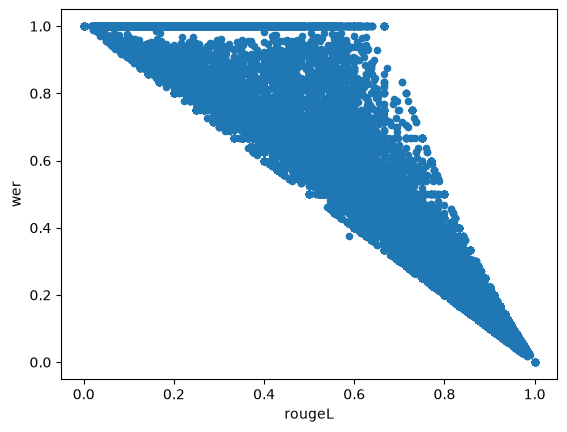

Pearson r: -0.9491
P-value: 0.0000


In [24]:
corr_analysis(df,'rougeL','wer')

<Axes: >

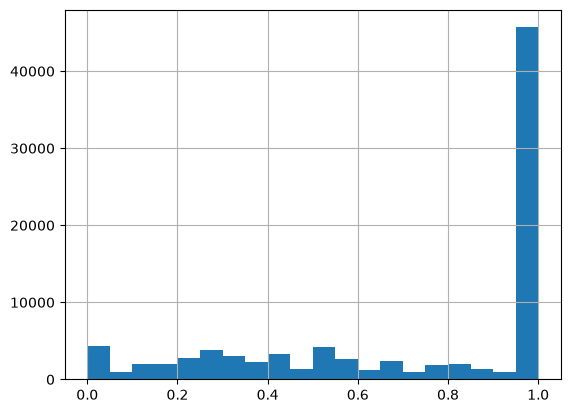

In [25]:
# Generate hist distr of WER
df['wer'].hist(bins=20)

In [26]:
# Look at mistranscriptions according to WER
df[errors_wer_idx][['text','gt','rougeL', 'wer']].sample(10)

,text,gt,rougeL,wer
22769,"Object, which would not be observed separately.",Oops.,0.000000,1.0
44220,you,Mm.,0.000000,1.0
48508,I'm a little bit tired of it.,That's always quite helpful.,0.000000,1.0
48453,"Why should we start? Well, I think the first thing",Where should we start?,0.428571,1.0
62777,Okay.,Great.,0.000000,1.0
20628,I'm sure you can check out our website.,Twelve fifty.,0.000000,1.0
1763,"It takes a lot of time to draw things and write things. Not very precise. We try to like, when you do this. Yeah, and should write your right- your name in a normal size, smaller? Yeah, smaller. Just when you're writing on a letter. Yeah, but that's not that you when you send an out of foreign audience you don't go to write that","Be it it takes a lot of time to draw things and to write things, and that's the Yeah, but that's not th the the you when you at a foreign audience, you b don't gonna wr uh write uh small.",0.471698,1.0
80389,"Nevermind, something...",Neither am I.,0.000000,1.0
76500,OK.,Okay.,0.000000,1.0
54620,"Me too, free.",Three.,0.000000,1.0


In [27]:
# Look at mistranscriptions according to ROUGEL
df[errors_rougeL_idx][['text','gt','rougeL', 'wer']].sample(10)

,text,gt,rougeL,wer
40492,you,Mm-hmm.,0.000000,1.0
42393,now let's not let him on it why I mean I made fell a little bit I don't know. I'll look at here,"No that's not what I want, I want Oh look it here.",0.285714,1.0
46192,It does ruin it but the fact that I took that decision or took this example actually not really a decision but the example is because we do offer the possibility of adding your own custom cover so you can change them into any color you want so it's just you deliver a basic remote control with the possibility to change into whatever you want.,"The people Spongy, yeah.",0.028986,1.0
31173,really.,"The temps, yeah.",0.000000,1.0
39709,I'll see you.,"Uh hello, we're great.",0.000000,1.0
53137,you,Alright.,0.000000,1.0
1541,But the signal,Yeah.,0.000000,1.0
63957,to the moment anyway so no and it's not bad.,So And it it's not that expensive.,0.470588,1.0
68187,That's not this question.,Fr Oh I mean the Oh never mind.,0.000000,1.0
60303,Thank you.,Hello.,0.000000,1.0


In [28]:
# Look at mistranscriptions according to WER
df[errors_wer_idx][['text','gt']].sample(10)

,text,gt
50433,okay,Mm-hmm.
74533,and two were all right.,"Yeah, two or a one, I guess."
72087,Arts?,Yeah.
23689,It's time to go right.,It can be curved.
55784,the guy,Wow.
45162,There are options for you.,Yes.
34986,you,Mm-hmm.
87383,you,Mm.
53036,Like an iPod.,That would be good.
29424,Are there access?,Um are there excess buttons?


In [29]:
print(df['rougeL'].describe())
rougeL_fifty = df['rougeL'].quantile(0.5)
print(f"50th quartile for rougeL is: {rougeL_fifty:.2f}")
rougeL_twentyfive = df['rougeL'].quantile(0.25)
print(f"25th quartile for rougeL is: {rougeL_twentyfive:.2f}")

count    88630.000000
mean         0.358234
std          0.362514
min          0.000000
25%          0.000000
50%          0.285714
75%          0.700000
max          1.000000
Name: rougeL, dtype: float64
50th quartile for rougeL is: 0.29
25th quartile for rougeL is: 0.00


In [30]:
errors_idx = errors_rougeL_idx

In [31]:
p_error = len(df[errors_idx])/len(df)
print(f"P(error) = {p_error:.3f}")
p_short = len(df[short_idx])/len(df)
print(f"P(short) = {p_short:.3f}")

p_error_given_short = len(df[(short_idx) & (errors_idx)]) / len(df[short_idx])
print(f"P(error|short) = {p_error_given_short:.3f}")

p_error_given_long = len(df[(~short_idx) & (errors_idx)]) / len(df[~short_idx])
print(f"P(error|long) = {p_error_given_long:.3f}")

p_short_given_error = len(df[(short_idx) & (errors_idx)]) / len(df[errors_idx])
print(f"P(short|error) = {p_short_given_error:.3f}")
print(f"P(long|error) = {1-p_short_given_error:.3f}")

P(error) = 0.592
P(short) = 0.418
P(error|short) = 0.844
P(error|long) = 0.412
P(short|error) = 0.595
P(long|error) = 0.405


In [32]:
from statsmodels.stats.proportion import proportions_ztest

# Number of errors in each group
n_errors_short = ((short_idx) & (errors_idx)).sum()
n_errors_long = ((~short_idx) & (errors_idx)).sum()

# Number of samples in each group
n_short = short_idx.sum()
n_long = (~short_idx).sum()

# Two-proportion z-test
count = [n_errors_short, n_errors_long]
nobs = [n_short, n_long]

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Short error rate: {n_errors_short/n_short:.3f}")
print(f"Long error rate:  {n_errors_long/n_long:.3f}")
print(f"z = {z_stat:.3f}")
print(f"p = {p_value:.6f}")

Short error rate: 0.844
Long error rate:  0.412
z = 129.070
p = 0.000000


# filtering for actual long utterances

<Axes: >

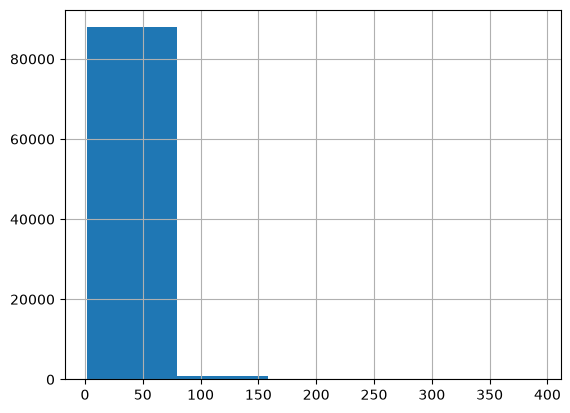

In [33]:
df['num_tokens_text'].hist(bins=5)

In [34]:
# Filter out for only actual phrases not just 'ummm' and 'ahhh' and 'yeahh'
longs_df = df[~short_idx]
shorts_df = df[short_idx]

In [35]:
# min_score = min(df['highest_score'])
# range_score = max(df['highest_score']) - min_score
# df['normalized_score'] = (df['highest_score'] - min_score)/range_score

# def standardize_df(datfram):
#     datfram['normalized_score'] = (
#         datfram['highest_score'] - datfram['highest_score'].mean()
#     )/datfram['highest_score'].std()

# standardize_df(df)
# standardize_df(shorts_df)
# standardize_df(longs_df)

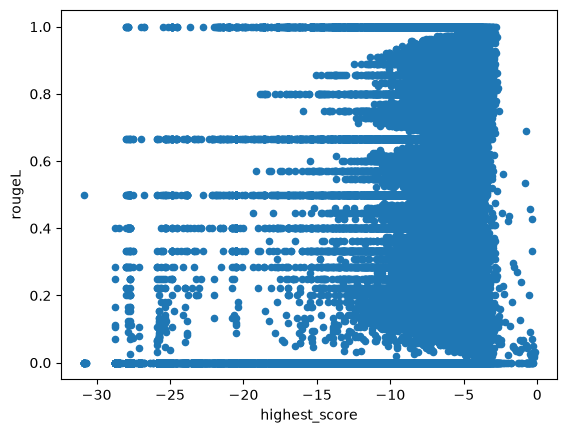

Pearson r: 0.5445
P-value: 0.0000


In [36]:
corr_analysis(df)

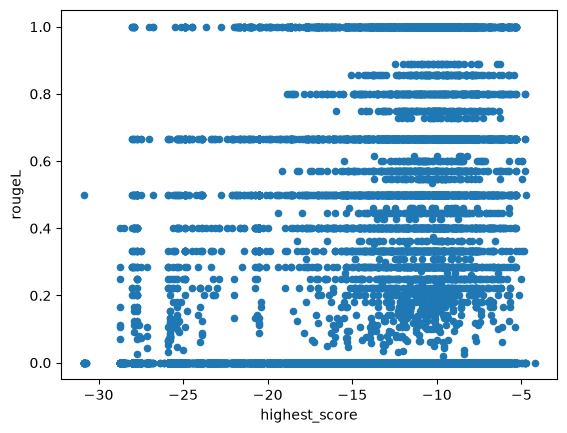

Pearson r: 0.3715
P-value: 0.0000


In [37]:
corr_analysis(shorts_df)

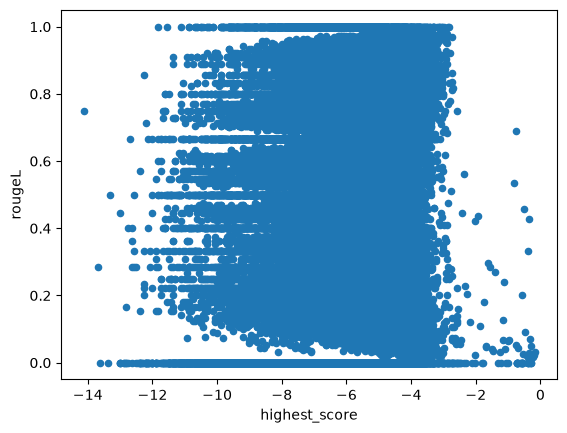

Pearson r: 0.2453
P-value: 0.0000


In [38]:
corr_analysis(longs_df)

<Axes: >

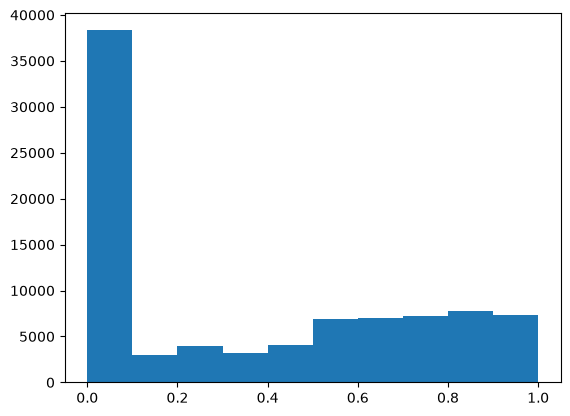

In [39]:
df['rougeL'].hist(grid=False, bins=10)

<Axes: >

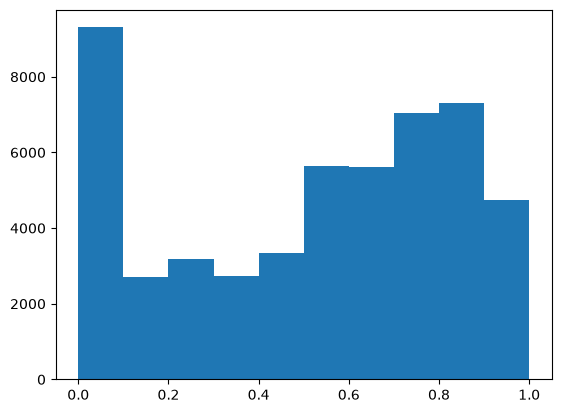

In [40]:
longs_df['rougeL'].hist(grid=False, bins=10)

<Axes: >

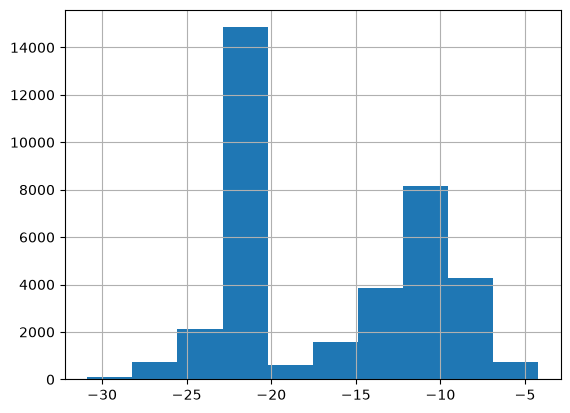

In [41]:
shorts_df['highest_score'].hist()

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score


def elbow_plot(
    df,
    log_prob_range=-10.0,
    mistranscription_label_threshold=0.3,
    metric_to_use="rougeL",
):
    """
    Plot F1 score for mistranscription detection as a function
    of avg_logprob threshold.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
            - avg_logprob
            - rougeL
            - rougeL_prec

    log_prob_range : float
        Lowest threshold to consider. Thresholds are swept from
        log_prob_range up to the maximum observed avg_logprob.

    mistranscription_label_threshold : float
        Ground-truth label threshold.

    metric_to_use : str
        Either 'rougeL' or 'rougeL_prec'
    """

    assert metric_to_use in ["rougeL", "rougeL_prec"]

    df = df.dropna(
        subset=["highest_score", metric_to_use]
    ).copy()

    # Ground-truth labels
    y_true = (
        df[metric_to_use]
        < mistranscription_label_threshold
    ).astype(int)

    thresholds = np.linspace(
        log_prob_range,
        df["highest_score"].max(),
        200,
    )

    f1s = []
    precs = []
    recs = []

    roc_auc = roc_auc_score(y_true, -df["highest_score"])
    
    for thresh in thresholds:
        y_pred = (
            (df["highest_score"] < thresh)
        ).astype(int)

        f1s.append(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        precs.append(
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        recs.append(
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

    best_idx = np.argmax(f1s)

    best_threshold = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    best_prec = precs[best_idx]
    best_rec = recs[best_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1s)

    plt.axvline(
        best_threshold,
        linestyle="--",
        alpha=0.7,
        label=f"best={best_threshold:.2f}",
    )

    plt.scatter(
        [best_threshold],
        [best_f1],
    )

    plt.xlabel("avg_logprob threshold")
    plt.ylabel("F1")
    plt.title(
        f"Mistranscription Detection\n"
        f"metric={metric_to_use}, "
        f"label threshold={mistranscription_label_threshold}"
    )

    plt.legend()
    plt.grid(True)

    print(
        f"Best threshold: {best_threshold:.4f}\n"
        f"ROCAUC: {roc_auc}\n"
        f"Best F1: {best_f1:.4f}\n"
        f"Precision at best F1: {best_prec:.4f}\n"
        f"Recall at best F1: {best_rec:.4f}\n"
    )

    plt.show()

    # return {
    #     "best_threshold": best_threshold,
    #     "best_f1": best_f1,
    #     "thresholds": thresholds,
    #     "f1s": f1s,
    # }

In [43]:
pd.set_option('display.max_colwidth', None)

Best threshold: -6.0024
ROCAUC: 0.7780192795474025
Best F1: 0.7633
Precision at best F1: 0.7018
Recall at best F1: 0.8366



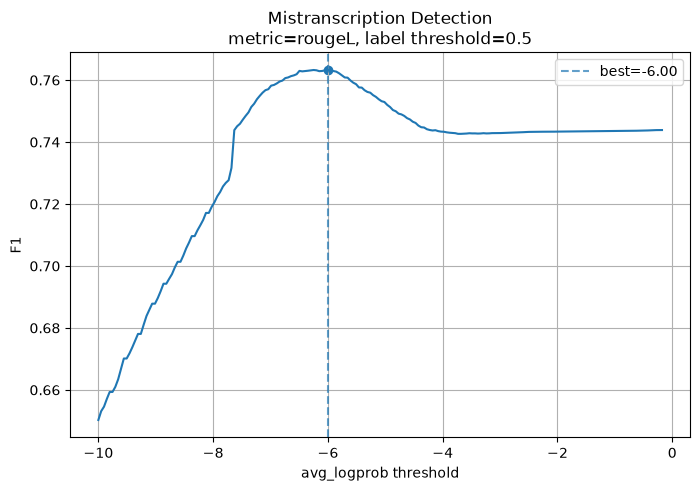

In [44]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=0.5)

Best threshold: -0.1787
ROCAUC: 0.6122547706434984
Best F1: 0.5833
Precision at best F1: 0.4118
Recall at best F1: 1.0000



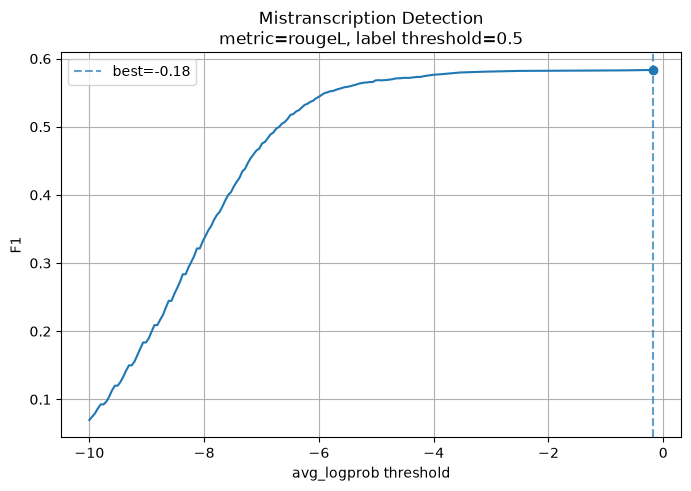

In [45]:
elbow_plot(longs_df, metric_to_use='rougeL', mistranscription_label_threshold=0.5)

Best threshold: -7.6310
ROCAUC: 0.805810761232689
Best F1: 0.7439
Precision at best F1: 0.7265
Recall at best F1: 0.7622



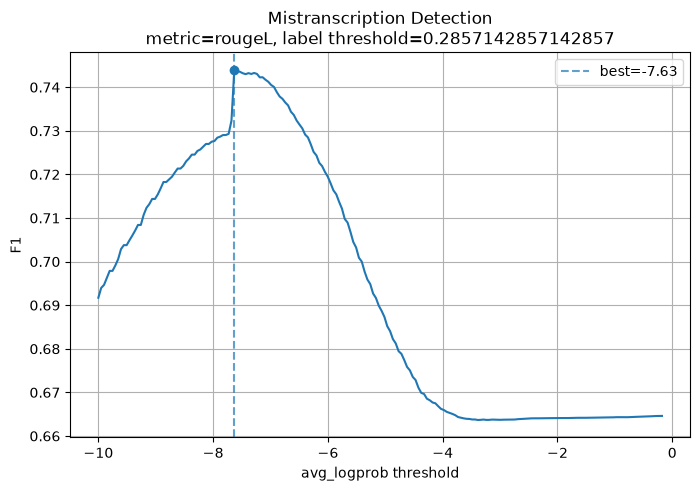

In [46]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)

Best threshold: -5.8543
ROCAUC: 0.598747238894001
Best F1: 0.4376
Precision at best F1: 0.3324
Recall at best F1: 0.6401



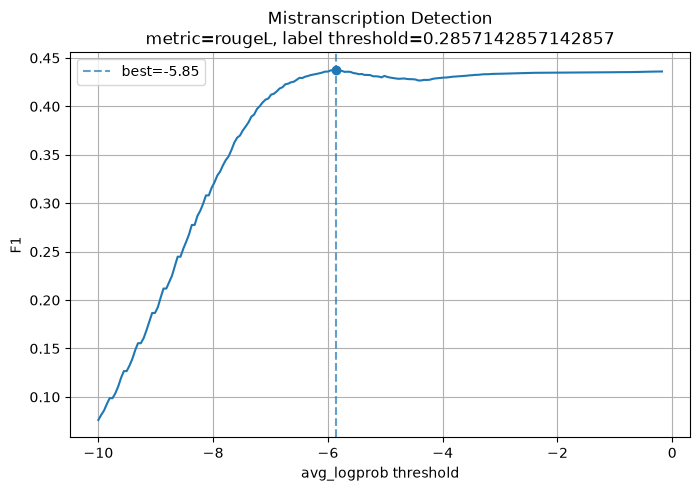

In [47]:
elbow_plot(longs_df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)

# ml stuff

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

df['y_true'] = errors_idx
df_val['y_true'] = df_val['rougeL'] < 0.5

FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
]

def train_and_eval_rf(FEATURES):
    TARGET = "y_true"
    
    # --------------------
    # Train RF
    # --------------------
    
    X_train = df[FEATURES]
    y_train = df[TARGET].astype(int)
    
    X_val = df_val[FEATURES]
    y_val = df_val[TARGET].astype(int)
    
    rf = RandomForestClassifier(
        n_estimators=1000,
        max_depth=None,
        min_samples_leaf=30,
        random_state=42,
        n_jobs=-1,
    )
    
    rf.fit(X_train, y_train)
    
    # --------------------
    # Predictions
    # --------------------
    
    train_probs = rf.predict_proba(X_train)[:, 1]
    val_probs = rf.predict_proba(X_val)[:, 1]
    
    # --------------------
    # Overall AUROC
    # --------------------
    
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    
    print(f"Train AUROC: {train_auc:.4f}")
    print(f"Val   AUROC: {val_auc:.4f}")
    
    # --------------------
    # Short / Long subsets
    # --------------------
    
    train_shorts_idx = df["num_tokens_text"] <= 5
    val_shorts_idx = df_val["num_tokens_text"] <= 5
    
    def subset_auc(y, probs, mask):
        if y[mask].nunique() < 2:
            return float("nan")
        return roc_auc_score(y[mask], probs[mask])
    
    print("\nTRAIN")
    print(
        f"Short AUROC: "
        f"{subset_auc(y_train, train_probs, train_shorts_idx):.4f}"
    )
    print(
        f"Long  AUROC: "
        f"{subset_auc(y_train, train_probs, ~train_shorts_idx):.4f}"
    )
    
    print("\nVALIDATION")
    print(
        f"Short AUROC: "
        f"{subset_auc(y_val, val_probs, val_shorts_idx):.4f}"
    )
    print(
        f"Long  AUROC: "
        f"{subset_auc(y_val, val_probs, ~val_shorts_idx):.4f}"
    )


    def elbow_plot(
        y_true,
        scores,
        threshold_range=None,
        n_thresholds=200,
    ):
        """
        Finds the threshold maximizing F1.
    
        Parameters
        ----------
        y_true : array-like of bool/int
            Ground truth labels (1 = error).
    
        scores : array-like
            Probability or score where LARGER means MORE likely to be an error.
    
        threshold_range : (min, max) or None
            Threshold search range. Defaults to score min/max.
    
        Returns
        -------
        best_threshold, best_f1, best_precision, best_recall
        """
    
        y_true = np.asarray(y_true).astype(int)
        scores = np.asarray(scores)
    
        if threshold_range is None:
            tmin = scores.min()
            tmax = scores.max()
        else:
            tmin, tmax = threshold_range
    
        thresholds = np.linspace(tmin, tmax, n_thresholds)
    
        f1s = []
        precisions = []
        recalls = []
    
        for t in thresholds:
            pred = scores >= t
    
            precisions.append(
                precision_score(y_true, pred, zero_division=0)
            )
            recalls.append(
                recall_score(y_true, pred, zero_division=0)
            )
            f1s.append(
                f1_score(y_true, pred, zero_division=0)
            )
    
        f1s = np.array(f1s)
        precisions = np.array(precisions)
        recalls = np.array(recalls)
    
        best_idx = np.argmax(f1s)
    
        best_threshold = thresholds[best_idx]
        best_f1 = f1s[best_idx]
        best_precision = precisions[best_idx]
        best_recall = recalls[best_idx]
    
        plt.figure(figsize=(7,4))
        plt.plot(thresholds, f1s, label="F1")
        plt.plot(thresholds, precisions, label="Precision")
        plt.plot(thresholds, recalls, label="Recall")
    
        plt.axvline(
            best_threshold,
            linestyle="--",
            label=f"Best threshold = {best_threshold:.3f}",
        )
    
        plt.xlabel("Threshold")
        plt.ylabel("Metric")
        plt.title("Threshold selection")
        plt.legend()
        plt.tight_layout()
        plt.show()
    
        print(f"Best threshold: {best_threshold:.4f}")
        print(f"Best F1:        {best_f1:.4f}")
        print(f"Precision:      {best_precision:.4f}")
        print(f"Recall:         {best_recall:.4f}")

    val_probs = rf.predict_proba(X_val)[:, 1]
    elbow_plot(y_val[~val_shorts_idx], val_probs[~val_shorts_idx])

    return rf

Train AUROC: 0.8347
Val   AUROC: 0.8073

TRAIN
Short AUROC: 0.8587
Long  AUROC: 0.7183

VALIDATION
Short AUROC: 0.8360
Long  AUROC: 0.6773


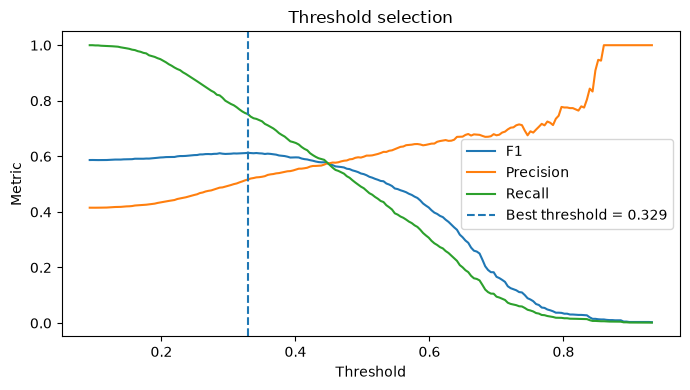

Best threshold: 0.3291
Best F1:        0.6125
Precision:      0.5167
Recall:         0.7520


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tot

In [55]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
]

train_and_eval_rf(FEATURES)

Train AUROC: 0.8884
Val   AUROC: 0.8617

TRAIN
Short AUROC: 0.8853
Long  AUROC: 0.8302

VALIDATION
Short AUROC: 0.8621
Long  AUROC: 0.7919


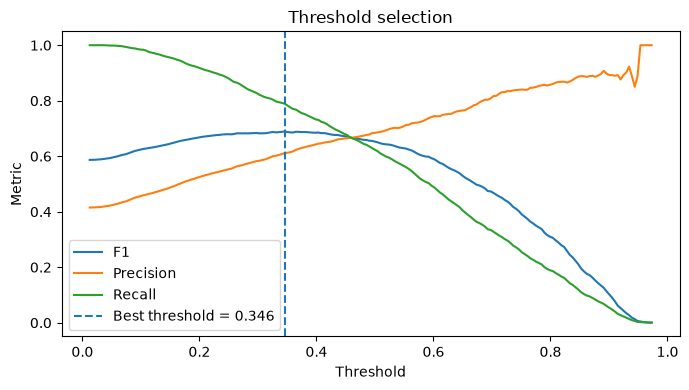

Best threshold: 0.3456
Best F1:        0.6890
Precision:      0.6113
Recall:         0.7895


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tot

In [56]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob"
]

train_and_eval_rf(FEATURES)

Train AUROC: 0.9066
Val   AUROC: 0.8750

TRAIN
Short AUROC: 0.9008
Long  AUROC: 0.8630

VALIDATION
Short AUROC: 0.8677
Long  AUROC: 0.8187


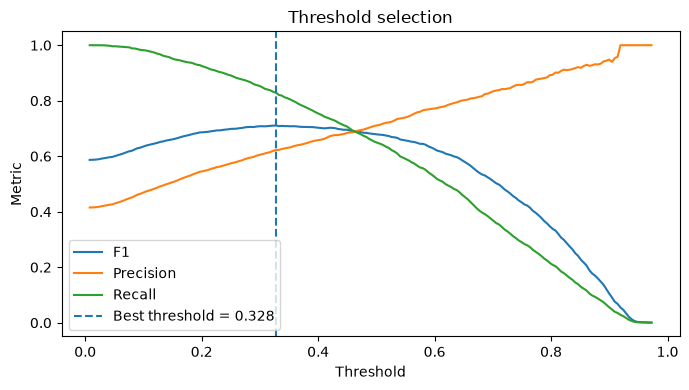

Best threshold: 0.3277
Best F1:        0.7110
Precision:      0.6224
Recall:         0.8289


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tot

In [57]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "beam_2_llmlogprob",
    "beam_2_asrlogprob",
    "beam_3_llmlogprob",
    "beam_3_asrlogprob",
]
train_and_eval_rf(FEATURES)

Train AUROC: 0.9121
Val   AUROC: 0.8758

TRAIN
Short AUROC: 0.9049
Long  AUROC: 0.8723

VALIDATION
Short AUROC: 0.8667
Long  AUROC: 0.8210


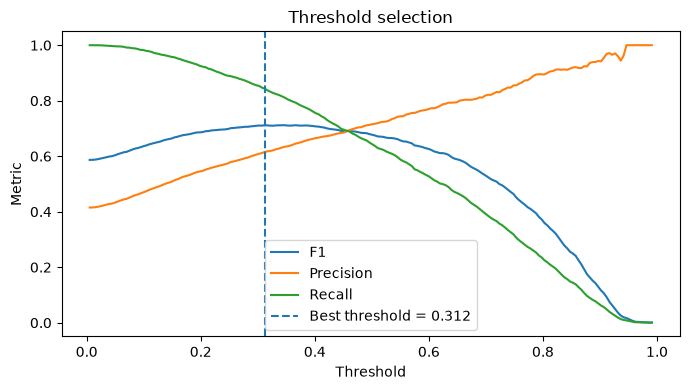

Best threshold: 0.3124
Best F1:        0.7118
Precision:      0.6159
Recall:         0.8431


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tot

In [58]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "beam_2_llmlogprob",
    "beam_2_asrlogprob",
    "beam_3_llmlogprob",
    "beam_3_asrlogprob",
    "max_llmlogprobs",
    "min_llmlogprobs",
    "spread_llmlogprobs",
    "max_asrlogprobs",
    "min_asrlogprobs",
    "spread_asrlogprobs",
]
train_and_eval_rf(FEATURES)

Train AUROC: 0.9111
Val   AUROC: 0.8761

TRAIN
Short AUROC: 0.9039
Long  AUROC: 0.8706

VALIDATION
Short AUROC: 0.8696
Long  AUROC: 0.8201


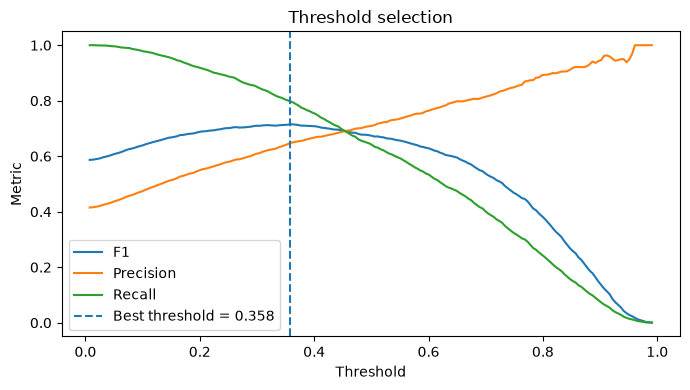

Best threshold: 0.3583
Best F1:        0.7152
Precision:      0.6485
Recall:         0.7972


In [59]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "max_llmlogprobs",
    "min_llmlogprobs",
    "spread_llmlogprobs",
    "max_asrlogprobs",
    "min_asrlogprobs",
    "spread_asrlogprobs",
]
rf = train_and_eval_rf(FEATURES)

In [60]:
os.getcwd()

'/home/pkongsomjit/Projects/llm_asr_clarification/src/llm_asr_clarification'

In [65]:
import pickle

# 1. Save your trained model
with open('/home/pkongsomjit/Projects/llm_asr_clarification/model_weights/rf_model.pkl', 'wb') as file:
    pickle.dump(rf, file)

# 2. Load your model back later
with open('/home/pkongsomjit/Projects/llm_asr_clarification/model_weights/rf_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# 3. Make predictions
predictions = loaded_model.predict(X_test)


NameError: name 'X_test' is not defined